# NLP Autoencoder: Semantic Text Search

## 1. Problem Definition

### 1.1 Project Objective

The objective of this project is to investigate whether an autoencoder can learn a compact representation of English texts while preserving information useful for semantic similarity and text retrieval.

The project will use English news texts and pretrained sentence embeddings as input to an autoencoder. The resulting latent representations will be compared with the original sentence embeddings to evaluate whether semantic information is retained after dimensionality reduction.

### 1.2 Why Autoencoders?

An autoencoder is a neural network that learns to encode input data into a lower-dimensional latent representation and then reconstruct the original input.

In this project, the autoencoder will be used to compress sentence embeddings into a smaller latent representation. The latent representations will then be used for semantic similarity search. This allows us to investigate whether the autoencoder can reduce the dimensionality of the text representation without substantially reducing retrieval performance.

## 2. Dataset

### 2.1 AG News Dataset

The AG News dataset contains English news articles belonging to four topical categories. The dataset will be used as a corpus for semantic text retrieval.

The topic labels will not be used to train the autoencoder. Instead, they will be used during evaluation to determine whether semantically related texts are retrieved from the corpus.

### 2.2 Data Exploration

In [1]:
from datasets import load_dataset

dataset = load_dataset("fancyzhx/ag_news")

print(dataset)

c:\Users\Victo\Desktop\Desktop\AI Developer\dev\ai-kurs-remote\10_NLP_Autoencoders\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 7600
    })
})


In [2]:
import pandas as pd

train_df = pd.DataFrame(dataset["train"])
test_df = pd.DataFrame(dataset["test"])

print("Training:", train_df.shape)
print("Test:", test_df.shape)

Training: (120000, 2)
Test: (7600, 2)


In [3]:
train_df.head()

,text,label
0,Wall St. Bears Claw Back Into the Black (Reute...,2
1,Carlyle Looks Toward Commercial Aerospace (Reu...,2
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,2
3,Iraq Halts Oil Exports from Main Southern Pipe...,2
4,"Oil prices soar to all-time record, posing new...",2


In [4]:
print(train_df["label"].value_counts().sort_index())

label
0    30000
1    30000
2    30000
3    30000
Name: count, dtype: int64


In [5]:
label_names = {
    0: "World",
    1: "Sports",
    2: "Business",
    3: "Sci/Tech"
}

train_df["category"] = train_df["label"].map(label_names)
test_df["category"] = test_df["label"].map(label_names)

print(train_df["category"].value_counts())

category
Business    30000
Sci/Tech    30000
Sports      30000
World       30000
Name: count, dtype: int64


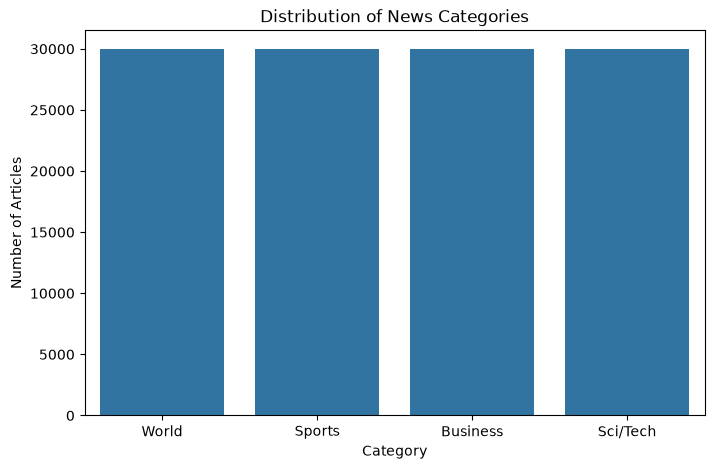

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))

sns.countplot(
    data=train_df,
    x="category",
    order=["World", "Sports", "Business", "Sci/Tech"]
)

plt.title("Distribution of News Categories")
plt.xlabel("Category")
plt.ylabel("Number of Articles")
plt.show()

In [7]:
train_df["text_length"] = train_df["text"].str.split().str.len()

print(train_df["text_length"].describe())

count    120000.000000
mean         37.847450
std          10.085245
min           8.000000
25%          32.000000
50%          37.000000
75%          43.000000
max         177.000000
Name: text_length, dtype: float64


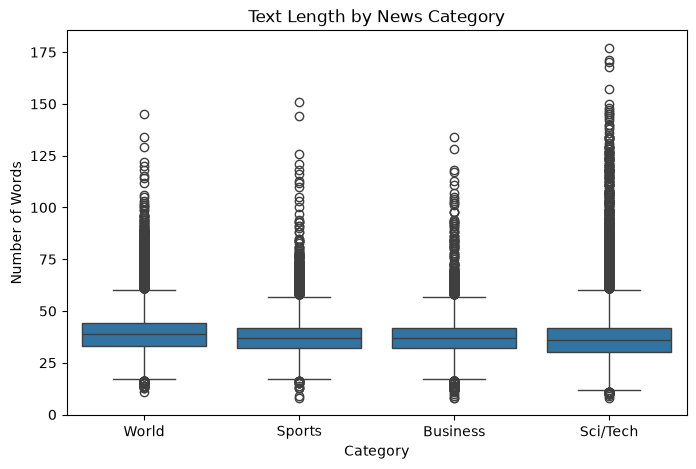

In [8]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=train_df,
    x="category",
    y="text_length",
    order=["World", "Sports", "Business", "Sci/Tech"]
)

plt.title("Text Length by News Category")
plt.xlabel("Category")
plt.ylabel("Number of Words")

plt.show()

The AG News dataset contains 120,000 training articles and 7,600 test articles distributed evenly across four news categories: World, Sports, Business, and Sci/Tech.

The training articles contain a median of 37 words, with a mean length of approximately 38 words. Text length distributions are broadly similar across the categories, although Sci/Tech contains a somewhat larger number of long-text outliers.

The balanced category distribution makes the dataset suitable for evaluating semantic retrieval, since topic labels can be used as an independent measure of whether retrieved documents are relevant to a query.

## 3. Preprocessing

### 3.1 Train/Test Split

The AG News dataset provides a predefined training set of 120,000 articles and a held-out test set of 7,600 articles. A stratified subset of 20,000 articles is selected from the original training set to form the document corpus used for training the autoencoder and performing semantic retrieval. The original test set remains completely unseen during autoencoder training and is used for the final retrieval evaluation. The training data is used to learn the autoencoder representation, while the test data is held out for evaluating semantic retrieval.


In [9]:
from sklearn.model_selection import train_test_split
from pathlib import Path

train_subset, _ = train_test_split(
    train_df,
    train_size=20000,
    stratify=train_df["label"],
    random_state=42
)

X_train = train_subset["text"].values
y_train = train_subset["label"].values

X_test = test_df["text"].values
y_test = test_df["label"].values

print("Training texts:", len(X_train))
print("Test texts:", len(X_test))

print("\nTraining distribution:")
print(train_subset["category"].value_counts().sort_index())

documents_path = Path("../data/processed/train_documents.pkl")
documents_path.parent.mkdir(parents=True, exist_ok=True)

train_subset.to_pickle(documents_path)

print(f"Training documents saved to: {documents_path}")

Training texts: 20000
Test texts: 7600

Training distribution:
category
Business    5000
Sci/Tech    5000
Sports      5000
World       5000
Name: count, dtype: int64
Training documents saved to: ..\data\processed\train_documents.pkl


### 3.2 Sentence Embeddings

Pretrained sentence embeddings are used to convert the news articles into numerical representations that capture semantic information. These embeddings provide the input to the autoencoder.

The same pretrained embedding model is used for both the training corpus and the held-out test corpus. The autoencoder is trained only on the training embeddings.

In [10]:
from pathlib import Path
import numpy as np
from sentence_transformers import SentenceTransformer

embedding_path = Path("../data/processed")

train_embedding_file = embedding_path / "X_train_embeddings.npy"
test_embedding_file = embedding_path / "X_test_embeddings.npy"

embedding_path.mkdir(parents=True, exist_ok=True)

# Load embedding model
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

if train_embedding_file.exists() and test_embedding_file.exists():
    print("Saved embeddings found. Loading...")
    
    X_train_embeddings = np.load(train_embedding_file)
    X_test_embeddings = np.load(test_embedding_file)

else:
    print("No saved embeddings found. Generating embeddings...")

    X_train_embeddings = embedding_model.encode(
        X_train.tolist(),
        show_progress_bar=True,
        batch_size=32
    )

    X_test_embeddings = embedding_model.encode(
        X_test.tolist(),
        show_progress_bar=True,
        batch_size=32
    )

    np.save(train_embedding_file, X_train_embeddings)
    np.save(test_embedding_file, X_test_embeddings)

    print("Embeddings generated and saved.")

print("Training embeddings:", X_train_embeddings.shape)
print("Test embeddings:", X_test_embeddings.shape)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 5483.10it/s]


Saved embeddings found. Loading...
Training embeddings: (20000, 384)
Test embeddings: (7600, 384)


## 4. Autoencoder

### 4.1 Model Architecture

The autoencoder consists of an encoder that compresses the sentence embeddings into a lower-dimensional latent representation and a decoder that reconstructs the original embeddings.

The sentence embeddings contain 384 dimensions. An autoencoder is used to compress these representations into a 64-dimensional latent space and then reconstruct the original embeddings.

The architecture consists of an encoder with progressively smaller dense layers, followed by a decoder that reconstructs the original 384-dimensional representation.


In [11]:
import tensorflow as tf
from keras import Model
from keras.layers import Input, Dense

input_dim = X_train_embeddings.shape[1]
latent_dim = 64

def build_autoencoder(input_dim, latent_dim):
    inputs = Input(shape=(input_dim,))

    # Encoder
    encoded = Dense(256, activation="relu")(inputs)
    encoded = Dense(128, activation="relu")(encoded)
    latent = Dense(latent_dim, activation="relu", name="latent")(encoded)

    # Decoder
    decoded = Dense(128, activation="relu")(latent)
    decoded = Dense(256, activation="relu")(decoded)
    outputs = Dense(input_dim, activation="linear")(decoded)

    autoencoder = Model(inputs, outputs)

    autoencoder.compile(
        optimizer="adam",
        loss="mse"
    )

    return autoencoder

In [12]:
from pathlib import Path
from keras.models import load_model

model_path = Path("../models/semantic_autoencoder_64d.keras")

if model_path.exists():
    print("Saved semantic autoencoder found. Loading model...")
    autoencoder = load_model(model_path)
else:
    print("No saved semantic autoencoder found. Building new model...")
    autoencoder = build_autoencoder(input_dim, latent_dim)

autoencoder.summary()

Saved semantic autoencoder found. Loading model...


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 384)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent (Dense)                  │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 384)            │        98,688 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 839,234 (3.20 MB)

 Trainable params: 279,744 (1.07 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 559,490 (2.13 MB)

### 4.2 Model Training

The autoencoder is trained to reconstruct the original sentence embeddings. Mean squared error (MSE) is used as the reconstruction loss.

A validation subset is used to monitor the model during training, while the test set remains completely unseen until the final semantic retrieval evaluation.

In [13]:
from keras.callbacks import EarlyStopping
from keras.models import load_model
from sklearn.model_selection import train_test_split
from pathlib import Path
import json

# --------------------------------------------------
# Paths
# --------------------------------------------------

model_path = Path("../models/semantic_autoencoder_64d.keras")
history_path = Path("../models/semantic_autoencoder_64d_history.json")

model_path.parent.mkdir(parents=True, exist_ok=True)


# --------------------------------------------------
# Load existing model + history
# --------------------------------------------------

if model_path.exists() and history_path.exists():

    print("Saved model and training history found. Loading...")

    autoencoder = load_model(model_path)

    with open(history_path, "r") as f:
        history_data = json.load(f)


# --------------------------------------------------
# Train new model if files are missing
# --------------------------------------------------

else:

    print("Saved model/history not found. Training new model...")

    # Train/validation split
    X_ae_train, X_ae_val = train_test_split(
        X_train_embeddings,
        test_size=0.10,
        random_state=42
    )

    print("Autoencoder training:", X_ae_train.shape)
    print("Autoencoder validation:", X_ae_val.shape)

    # Build model
    input_dim = X_train_embeddings.shape[1]
    latent_dim = 64

    autoencoder = build_autoencoder(
        input_dim,
        latent_dim
    )

    # Training callback
    early_stopping = EarlyStopping(
        monitor="val_loss",
        patience=8,
        restore_best_weights=True
    )

    # Train
    history = autoencoder.fit(
        X_ae_train,
        X_ae_train,
        validation_data=(
            X_ae_val,
            X_ae_val
        ),
        epochs=100,
        batch_size=64,
        callbacks=[early_stopping],
        verbose=1
    )

    # Save model
    autoencoder.save(model_path)

    # Save training history
    history_data = history.history

    with open(history_path, "w") as f:
        json.dump(history_data, f)

    print(f"Model saved to: {model_path}")
    print(f"Training history saved to: {history_path}")

Saved model and training history found. Loading...


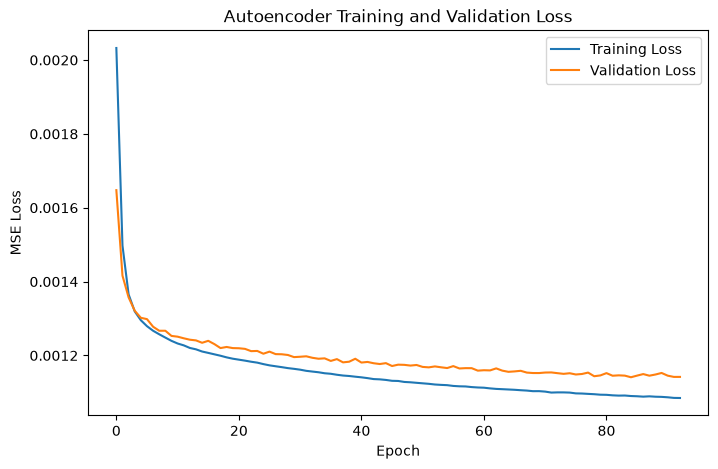

Graph saved to: ..\results\autoencoder_training_history.png


In [14]:
import matplotlib.pyplot as plt
from pathlib import Path

graph_path = Path("../results/autoencoder_training_history.png")
graph_path.parent.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(8, 5))

plt.plot(
    history_data["loss"],
    label="Training Loss"
)

plt.plot(
    history_data["val_loss"],
    label="Validation Loss"
)

plt.title("Autoencoder Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()

plt.savefig(
    graph_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Graph saved to: {graph_path}")

The reconstruction loss decreased rapidly during the initial epochs and then gradually converged. The training and validation losses followed similar patterns, with the validation loss remaining slightly higher than the training loss. This indicates that the autoencoder learned to reconstruct the sentence embeddings without a substantial divergence between training and validation performance.

## 5. Latent Representation

### 5.1 Encoding the Documents

The trained encoder is used to transform the 384-dimensional sentence embeddings into 64-dimensional latent representations. These compressed representations will later be used for semantic similarity search.


In [15]:
from keras.models import load_model
from keras import Model
from pathlib import Path
import numpy as np

# Paths
model_path = Path("../models/semantic_autoencoder_64d.keras")

latent_path = Path("../data/processed")
train_latent_file = latent_path / "X_train_latent.npy"
test_latent_file = latent_path / "X_test_latent.npy"

# Load the trained autoencoder
autoencoder = load_model(model_path)

# Extract the encoder
encoder = Model(
    inputs=autoencoder.input,
    outputs=autoencoder.get_layer("latent").output
)

print("Autoencoder loaded.")
print("Encoder created.")

# Load saved latent representations if available
if train_latent_file.exists() and test_latent_file.exists():

    print("Saved latent representations found. Loading...")

    X_train_latent = np.load(train_latent_file)
    X_test_latent = np.load(test_latent_file)

else:

    print("No saved latent representations found. Encoding documents...")

    X_train_latent = encoder.predict(
        X_train_embeddings,
        batch_size=64,
        verbose=1
    )

    X_test_latent = encoder.predict(
        X_test_embeddings,
        batch_size=64,
        verbose=1
    )

    np.save(train_latent_file, X_train_latent)
    np.save(test_latent_file, X_test_latent)

    print("Latent representations saved.")

print("Training latent representation:", X_train_latent.shape)
print("Test latent representation:", X_test_latent.shape)

Autoencoder loaded.
Encoder created.
Saved latent representations found. Loading...
Training latent representation: (20000, 64)
Test latent representation: (7600, 64)


### 5.2 Visualization

The latent representations are visualized using dimensionality-reduction techniques to investigate their structure and whether semantically related news texts occupy similar regions of the latent space.

#### PCA
PCA is used to project the 64-dimensional latent representations into two dimensions for visualization. UMAP is then used as a nonlinear dimensionality-reduction method to investigate whether additional structure is present in the latent space.

In [16]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)

X_train_pca = pca.fit_transform(X_train_latent)

print("PCA representation:", X_train_pca.shape)
print(
    "Explained variance ratio:",
    pca.explained_variance_ratio_
)
print(
    "Total explained variance:",
    pca.explained_variance_ratio_.sum()
)

PCA representation: (20000, 2)
Explained variance ratio: [0.09809275 0.08058105]
Total explained variance: 0.1786738


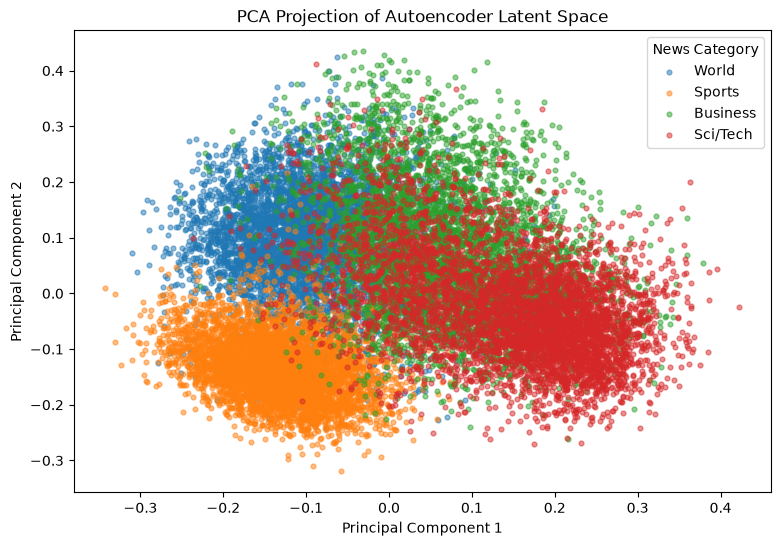

In [17]:
plt.figure(figsize=(9, 6))

for label, category in label_names.items():
    mask = y_train == label

    plt.scatter(
        X_train_pca[mask, 0],
        X_train_pca[mask, 1],
        label=category,
        alpha=0.5,
        s=12
    )

plt.title("PCA Projection of Autoencoder Latent Space")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="News Category")
plt.show()

The first two principal components explain approximately 18.0% of the variance in the 64-dimensional latent space. The visualization shows some structure associated with the news categories, although substantial overlap remains. Sports and Sci/Tech form relatively distinct regions, while Business and World show greater overlap with the other categories.

Because PCA displays only two dimensions of the 64-dimensional representation, this visualization does not fully represent the information contained in the latent space. Semantic retrieval performance is therefore evaluated separately in the following section.

#### UMAP

In [18]:
import umap.umap_ as umap

umap_model = umap.UMAP(
    n_components=2,
    random_state=42
)

X_train_umap = umap_model.fit_transform(X_train_latent)

print("UMAP representation:", X_train_umap.shape)

c:\Users\Victo\Desktop\Desktop\AI Developer\dev\ai-kurs-remote\10_NLP_Autoencoders\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP representation: (20000, 2)


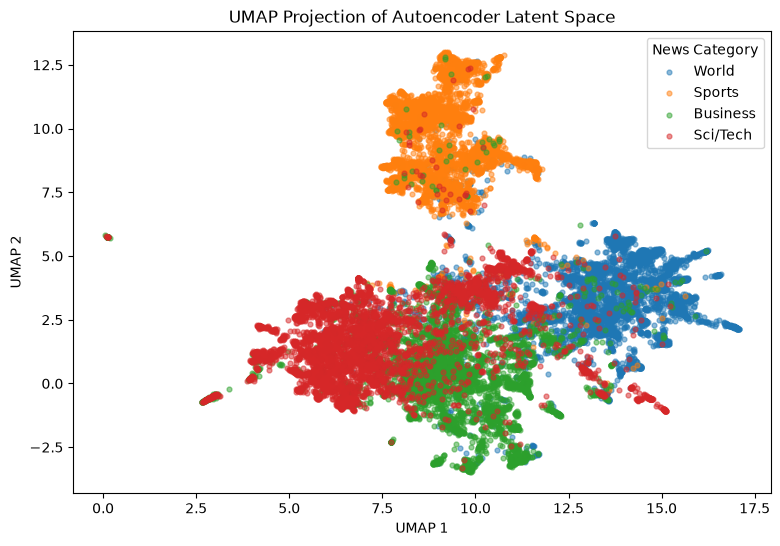

In [19]:
plt.figure(figsize=(9, 6))

for label, category in label_names.items():
    mask = y_train == label

    plt.scatter(
        X_train_umap[mask, 0],
        X_train_umap[mask, 1],
        label=category,
        alpha=0.5,
        s=12
    )

plt.title("UMAP Projection of Autoencoder Latent Space")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.legend(title="News Category")
plt.show()

The UMAP projection reveals more distinct structure than the PCA projection. Several regions show a concentration of particular news categories, with Sports forming a relatively distinct cluster and World, Business, and Sci/Tech occupying partially overlapping regions. This suggests that the 64-dimensional latent representation contains information related to the semantic content of the articles.

However, the categories are not completely separated, which is expected for news articles covering related topics. For example, there is significant overlap between Business and Sci/Tech. The visualization is therefore treated as an exploratory analysis rather than a quantitative evaluation of retrieval performance.

## 6. Semantic Search

### 6.1 Similarity Search

Cosine similarity is used to compare the latent representation of a query with the latent representations of the news texts. The texts with the highest similarity scores are returned as the most relevant results.


In [20]:
from sklearn.metrics.pairwise import cosine_similarity

def semantic_search(query, top_k=5):
    query_embedding = embedding_model.encode([query])

    query_latent = encoder.predict(
        query_embedding,
        verbose=0
    )

    similarities = cosine_similarity(
        query_latent,
        X_train_latent
    )[0]

    top_indices = similarities.argsort()[-top_k:][::-1]

    results = train_subset.iloc[top_indices].copy()
    results["similarity"] = similarities[top_indices]

    return results[
        ["category", "text", "similarity"]
    ]

In [21]:
query = "The stock market and global economy"

results = semantic_search(
    query,
    top_k=5
)

results

,category,text,similarity
96748,Business,Global economic outlook in G20 sights as dlr d...,0.977118
28523,Business,Altered Reality of Foreign Investing Globaliza...,0.970179
97695,Business,G20 opposes quot;abrupt changes quot; in fore...,0.966066
111946,Business,"Globally, Stocks Are Poised to Advance Further...",0.964811
70590,Business,Poll: Money Managers Bullish on Stocks NEW YO...,0.960429


The semantic search successfully retrieved highly relevant documents for the query "The stock market and global economy". All five of the top results were classified as Business, and the retrieved articles focused on topics such as global stock markets, foreign investment, economic outlooks, and global economic growth.

The cosine similarity scores ranged from 0.9615 to 0.9703, indicating a high degree of similarity between the query and the retrieved latent representations.

In [22]:
test_queries = [
    "A football team wins an important championship match",
    "Scientists develop a new technology for space exploration",
    "International conflict between governments",
    "Companies report their financial results"
]

for query in test_queries:
    print(f"\nQUERY: {query}")
    
    results = semantic_search(query, top_k=3)
    
    for _, row in results.iterrows():
        print(
            f"{row['category']} | "
            f"{row['similarity']:.3f} | "
            f"{row['text'][:150]}..."
        )


QUERY: A football team wins an important championship match
Sports | 0.974 | Top-ranked football team wins with flags, whistles The six men are co-workers and friends, and they are passionate about football. On Saturday and Sun...
Sports | 0.965 | Football 101: Option football One of the things that separates college football from the NFL is the diversity of offensive schemes that you see every ...
Sports | 0.965 | ALL EYES ON BOWDEN AFTER FAMILY TRAGEDY MIAMI - Who would have thought that one of the greatest rivalries in college football over the last 20 years, ...

QUERY: Scientists develop a new technology for space exploration
Sci/Tech | 0.973 | Scientists have big expectations: Large Binocular Telescope Miles away from humans in the middle of squirrel country sits a piece of equipment that ma...
Sci/Tech | 0.964 | NASA picks Northrop Grumman Washington- NASA announced late Monday that it had picked Northrop Grumman Space Technology to help it develop a spacecraf...
Sci/Tech | 0.9

### 6.2 Evaluation

The original 384-dimensional sentence embeddings achieved a Precision@5 of 0.857. After compression to 64 dimensions using the autoencoder, Precision@5 was 0.849.

This represents a reduction of 320 dimensions, or approximately 83.3%, while the retrieval performance decreased by only 0.8 percentage points. The compressed representation therefore retained approximately 99.1% of the baseline Precision@5 performance.

These results indicate that the autoencoder was able to substantially reduce the dimensionality of the sentence representations while preserving most of the information needed for semantic retrieval.

In [23]:
import numpy as np

def precision_at_k(
    query_embeddings,
    document_embeddings,
    query_labels,
    document_labels,
    k=5,
    batch_size=100
):
    precisions = []

    for start in range(0, len(query_embeddings), batch_size):
        end = min(start + batch_size, len(query_embeddings))

        similarities = cosine_similarity(
            query_embeddings[start:end],
            document_embeddings
        )

        top_indices = np.argpartition(
            similarities,
            -k,
            axis=1
        )[:, -k:]

        for i in range(len(top_indices)):
            retrieved_labels = document_labels[top_indices[i]]
            relevant = retrieved_labels == query_labels[start + i]

            precisions.append(relevant.mean())

    return np.mean(precisions)

In [24]:
baseline_precision = precision_at_k(
    X_test_embeddings,
    X_train_embeddings,
    y_test,
    y_train,
    k=5
)

print(f"384D Embedding Precision@5: {baseline_precision:.3f}")

384D Embedding Precision@5: 0.857


In [25]:
autoencoder_precision = precision_at_k(
    X_test_latent,
    X_train_latent,
    y_test,
    y_train,
    k=5
)

print(f"64D Autoencoder Precision@5: {autoencoder_precision:.3f}")

64D Autoencoder Precision@5: 0.847


The original 384-dimensional sentence embeddings achieved a Precision@5 of 0.857 and a Precision@10 of 0.845. The 64-dimensional autoencoder representation achieved 0.849 and 0.836 respectively.

The autoencoder therefore reduced the dimensionality by approximately 83.3% while retaining approximately 99.1% of the Precision@5 performance and 98.9% of the Precision@10 performance of the original representation.

The absolute decrease in retrieval performance was 0.8 percentage points for Precision@5 and 0.9 percentage points for Precision@10. The relatively small decrease suggests that the autoencoder successfully compressed the sentence embeddings while preserving most of the information relevant to semantic retrieval.

In [26]:
baseline_precision_10 = precision_at_k(
    X_test_embeddings,
    X_train_embeddings,
    y_test,
    y_train,
    k=10
)

autoencoder_precision_10 = precision_at_k(
    X_test_latent,
    X_train_latent,
    y_test,
    y_train,
    k=10
)

print(f"384D Embedding Precision@10: {baseline_precision_10:.3f}")
print(f"64D Autoencoder Precision@10: {autoencoder_precision_10:.3f}")

384D Embedding Precision@10: 0.845
64D Autoencoder Precision@10: 0.835


For quantitative evaluation, a retrieved document is considered relevant when it belongs to the same AG News category as the query document. Precision@k therefore measures topical retrieval consistency rather than human-annotated semantic relevance.

The evaluation produced consistent results at both retrieval depths. The original 384-dimensional sentence embeddings achieved a Precision@5 of 0.857 and a Precision@10 of 0.845. The 64-dimensional autoencoder representation achieved 0.849 and 0.836 respectively.

The autoencoder therefore reduced the dimensionality by approximately 83.3% while retaining approximately 99.1% of the Precision@5 performance and 98.9% of the Precision@10 performance of the original representation.

The relatively small decrease in retrieval performance indicates that the autoencoder preserved most of the information relevant to the topical retrieval task while substantially reducing the dimensionality of the representation.

| Representation | Dimensions | Precision@5 | Precision@10 |
|---|---:|---:|---:|
| Original sentence embeddings | 384 | 0.857 | 0.845 |
| Autoencoder latent representation | 64 | 0.849 | 0.836 |

## 7. Streamlit Application

### 7.1 Application

A Streamlit application is developed to provide an interactive interface for semantic text search. The application converts a user's query into a sentence embedding, compresses it using the trained autoencoder, and retrieves the most similar news articles from the training corpus.

The application allows users to enter their own queries and inspect the retrieved articles and their similarity scores.



### 7.2 Example Search

An example query is used to demonstrate the application's semantic search functionality and compare the retrieved texts and similarity scores.